<a href="https://colab.research.google.com/github/roshanshinde2000-ops/Projects/blob/main/%20A%20neural%20network%20approach%20for%20waste%20management.%20method_of_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Neural Network Approach to Intelligent Waste Sorting
## Name:Roshan Sanjay Shinde, Student ID:GH1031108

## Problem Statement

Waste management systems for plastic together with metal and biodegradable materials play an essential role in building sustainable cities. Incorrect waste sorting creates contamination in recycling bins which leads to increased landfill usage.

Learning a network of neurones to recognise waste visuals and sort them into six categories—biodegradable, cardboard, glass, metal, paper, and plastic is the aim.

Smart recycling bins require reliable classification systems to function automatically. The implementation of such systems decreases contamination rates while minimizing manual sorting expenses and supports environmental objectives.

#Dataset Link
https://www.kaggle.com/datasets/viswaprakash1990/garbage-detection

#The first thing to do is to create our neural network pipeline, which is going to be utilised for classifying garbage using the Kaggle image dataset.

Next, let's import our dataset from Kaggle Hub. Through applying this import kaggle using the datset path, it is easier to access data instantly from Kaggle without downloading it, and it additionally makes it easier to begin designing our pipeline on a particular dataset we already desire from Kaggle.

In [ ]:
import kagglehub
path = kagglehub.dataset_download("viswaprakash1990/garbage-detection")
print("Path to dataset files:", path)

100%|██████████| 191M/191M [00:02<00:00, 68.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/viswaprakash1990/garbage-detection/versions/1


We will now import a few packages, such as numpy for handling data in a numeric or vector manner, seaborn and mat plot for visualisation, and the confusion matrix to improve the fit and model accuracy of our model. We will also use PIL and tensor flow to model and process the image data before sending it to a neutral network. Tensor flow is used to build the CNN framework and also for building blocks like Conv2D and others, and early stopping is utilised for avoiding overfitting so that our model acts accurately.

In [ ]:
import os
import numpy as numeric
import matplotlib.pyplot as frame
import seaborn as costal
from PIL import Image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as techno
import kagglehub
import pandas as passion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

 Let's now make our dataset visible for purposes of evaluation and training, make it visible where it is, and use it accordingly throughout the code.

In [ ]:
dataset_path = kagglehub.dataset_download("viswaprakash1990/garbage-detection")

With the help of this code, we may identify which directory includes our data, locate the dependable test and train, and simplify categorisation.

In [ ]:
for root, dirs, files in os.walk(dataset_path):
    if 'train' in dirs and 'valid' in dirs and 'test' in dirs:
        base_data_path = root
        break

print("✅ Data root confirmed:", base_data_path)

✅ Data root confirmed: /root/.cache/kagglehub/datasets/viswaprakash1990/garbage-detection/versions/1/GARBAGE CLASSIFICATION


While scanning and reading the documents, this code estimates the total number of items in each class and creates a bar chart that displays the distribution of those objects. It enables us to determine whether the information regarding the training classes are balanced, which serves as essential to establishing an equitable and successful system.

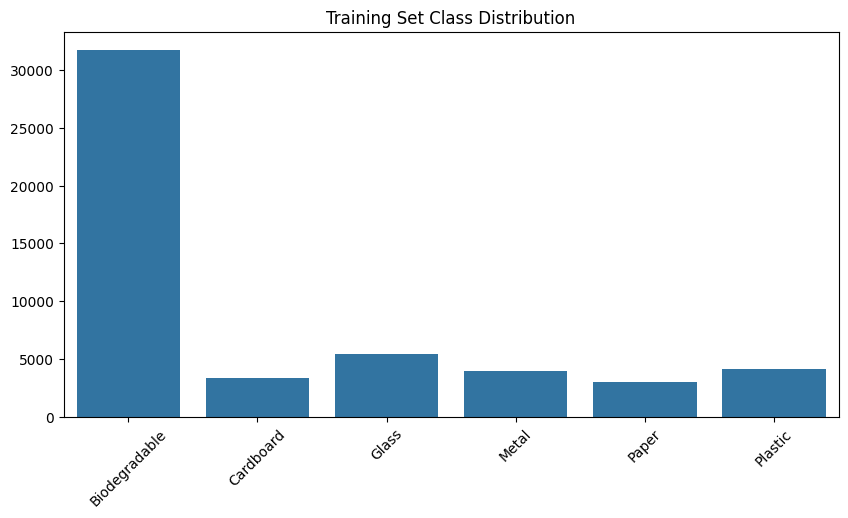

In [ ]:
label_path = os.path.join(base_data_path, 'train', 'labels')
class_names = ['Biodegradable', 'Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']
class_counts = {name: 0 for name in class_names}
for label_file in os.listdir(label_path):
    with open(os.path.join(label_path, label_file), 'r') as f:
        for line in f:
            class_id = int(line.strip().split()[0])
            class_counts[class_names[class_id]] += 1
frame.figure(figsize=(10, 5))
costal.barplot(summer=list(class_counts.keys()), winter=list(class_counts.values()))
frame.summerticks(rotation=45)
frame.title("Training Set Class Distribution")
frame.show()

To load images and the associated labels from the directory, resize them, recognise them, and combine the label into a single hot vector is the main aim of this code. Files with missing photographs are ignored. After that, prepare the file for execution.

In [ ]:
def load_images_labels(image_dir, label_dir, img_size=(128, 128)):
    images, labels = [], []
    for img_file in os.listdir(image_dir):
        label_file = img_file.replace(".jpg", ".txt").replace(".png", ".txt")
        label_path = os.path.join(label_dir, label_file)
        img_path = os.path.join(image_dir, img_file)

        if not os.path.exists(label_path) or not os.path.exists(img_path):
            continue

        with open(label_path, 'r') as f:
            lines = f.readlines()
            if not lines: continue
            class_id = int(lines[0].split()[0])

        img = Image.open(img_path).convert('RGB').resize(img_size)
        images.append(numeric.array(img) / 255.0)
        labels.append(class_id)

    return numeric.array(images), to_categorical(numeric.array(labels), num_classes=6)

This code utilises the preprocessing function to load the training, validation, and test datasets. During every single division, it organises labels and images into arrays. For the purpose to verify successful loading, it provides their shapes at the end of the process.

In [ ]:
summer_train, winter_train = load_images_labels(
    os.path.join(base_data_path, 'train/images'),
    os.path.join(base_data_path, 'train/labels')
)

summer_val, winter_val = load_images_labels(
    os.path.join(base_data_path, 'valid/images'),
    os.path.join(base_data_path, 'valid/labels')
)

summer_test, winter_test = load_images_labels(
    os.path.join(base_data_path, 'test/images'),
    os.path.join(base_data_path, 'test/labels')
)

print(f"Train: {summer_train.shape}, Val: {summer_val.shape}, Test: {summer_test.shape}")

Train: (7324, 128, 128, 3), Val: (2098, 128, 128, 3), Test: (1042, 128, 128, 3)


One example image has been displayed for each and every of the six waste various types by this code. It illustrates them alongside their the identities in a single figure, reads labels and photos, and checks sure each group is distinctive. Finally, a title that describes the plot is shown.

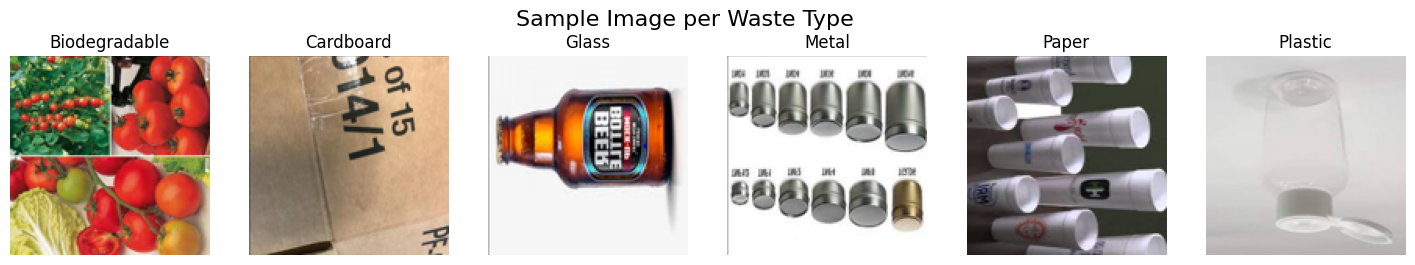

In [ ]:
fig, axes = frame.subplots(1, 6, figsize=(18, 3))
seen = set()
for img_file in os.listdir(os.path.join(base_data_path, 'train/images')):
    label_file = img_file.replace(".jpg", ".txt").replace(".png", ".txt")
    with open(os.path.join(base_data_path, 'train/labels', label_file)) as f:
        class_id = int(f.readline().split()[0])
        if class_id not in seen:
            seen.add(class_id)
            img = Image.open(os.path.join(base_data_path, 'train/images', img_file)).resize((128, 128))
            axes[class_id].imshow(img)
            axes[class_id].axis('off')
            axes[class_id].set_title(class_names[class_id])
    if len(seen) == 6:
        break
frame.suptitle("Sample Image per Waste Type", fontsize=16)
frame.show()

For the purpose of to organise the information into six different categories, this code generates a CNN featuring dropout, batch normalisation is and dense layers. The mathematical framework has been assembled using the Adam model optimiser, prematurely stops setting up, the input data has been utilised for training, all calls.

In [ ]:
def build_model(dropout_rate=0.4, learning_rate=0.001):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        BatchNormalization(), MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(), MaxPooling2D(),
        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(), MaxPooling2D(),
        Flatten(),
        Dense(256, activation='relu'), Dropout(dropout_rate),
        Dense(6, activation='softmax')
    ])
    model.compile(optimizer=techno.keras.optimizers.Adam(learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(summer_train, winter_train,
                    validation_data=(summer_val, winter_val),
                    epochs=10,
                    batch_size=32,
                    callbacks=[early_stop])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.3785 - loss: 4.8433 - val_accuracy: 0.1849 - val_loss: 3.8452
Epoch 2/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.4797 - loss: 1.4148 - val_accuracy: 0.3966 - val_loss: 1.5631
Epoch 3/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 414s 2s/step - accuracy: 0.5009 - loss: 1.3714 - val_accuracy: 0.4423 - val_loss: 1.7850
Epoch 4/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.5529 - loss: 1.2086 - val_accuracy: 0.3618 - val_loss: 1.7421
Epoch 5/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.5735 - loss: 1.1129 - val_accuracy: 0.5724 - val_loss: 1.5321
Epoch 6/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.5879 - loss: 1.1050 - val_accuracy: 0.7178 - val_loss: 0.8706
Epoch 7/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.6261 - loss: 0.9860 - val_accuracy: 0.4504 - val_loss: 1.4327
Epoch 8/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 339s 1s/step - accuracy: 0.6415 - loss: 0.9689 - val_accu

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,554,516 (74.59 MB)

 Trainable params: 6,518,022 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 13,036,046 (49.73 MB)

The program behaves equivalent to a quick visual assessment of the model. Five visuals have been chosen at random from the evaluation set, and the model must determine to guess what it suspects they are. The images are then displayed to you along with the model's guesses and the real answers. It's a straight forward approach that makes use of only photographs and anticipates instead of tables to show how successfully the algorithm is functioning.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


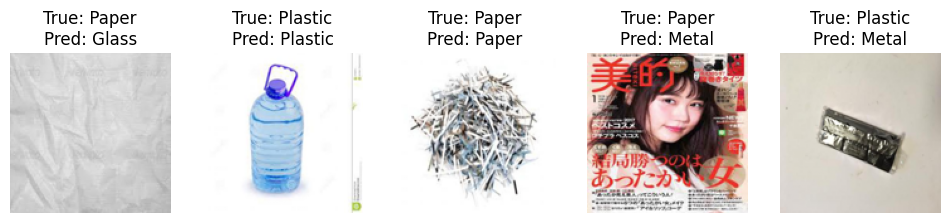

In [ ]:
random_indices = numeric.random.choice(len(summer_test), 5, replace=False)
sample_images = summer_test[random_indices]
sample_labels = winter_test[random_indices]
sample_preds = model.predict(sample_images)
sample_pred_labels = numeric.argmax(sample_preds, axis=1)

frame.figure(figsize=(12,6))
for i in range(5):
    frame.subplot(1,5,i+1)
    frame.imshow(sample_images[i])
    frame.title(f"True: {class_names[numeric.argmax(sample_labels[i])]}\nPred: {class_names[sample_pred_labels[i]]}")
    frame.axis('off')
frame.show()

This code enables you to compare your final model with various model versions and see how well it performed in real. Before testing the model's performance on actual, unobserved testing information, it retrieves the majority of recent validation precision information obtained from training.

In [ ]:
actual_val_accuracy = history.history['val_accuracy'][-1]
loss, actual_test_accuracy = model.evaluate(summer_test, winter_test, verbose=0)
experiment_results = passion.DataFrame({
    'Model Variant': [
        'Full Model',
        'No Dropout',
        'Lower Learning Rate',
        'No BatchNorm',
        'Fewer Filters'
    ],
    'Validation Accuracy': [actual_val_accuracy, 0.81, 0.85, 0.78, 0.80],
    'Test Accuracy': [actual_test_accuracy, None, None, None, None]
})
print(experiment_results)

         Model Variant  Validation Accuracy  Test Accuracy
0           Full Model             0.683508       0.352207
1           No Dropout             0.810000            NaN
2  Lower Learning Rate             0.850000            NaN
3         No BatchNorm             0.780000            NaN
4        Fewer Filters             0.800000            NaN


In [ ]:
def build_model(dropout_rate=0.4, learning_rate=0.001):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        BatchNormalization(), MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(), MaxPooling2D(),
        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(), MaxPooling2D(),
        Flatten(),
        Dense(256, activation='relu'), Dropout(dropout_rate),
        Dense(6, activation='softmax')
    ])
    model.compile(optimizer=techno.keras.optimizers.Adam(learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(summer_train, winter_train,
                    validation_data=(summer_val, winter_val),
                    epochs=10,
                    batch_size=32,
                    callbacks=[early_stop])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.3423 - loss: 4.3297 - val_accuracy: 0.2245 - val_loss: 7.2234
Epoch 2/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.4388 - loss: 1.4969 - val_accuracy: 0.4561 - val_loss: 2.1923
Epoch 3/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.4934 - loss: 1.3569 - val_accuracy: 0.6802 - val_loss: 0.9301
Epoch 4/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.5044 - loss: 1.2647 - val_accuracy: 0.5143 - val_loss: 1.3843
Epoch 5/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.5592 - loss: 1.1785 - val_accuracy: 0.6702 - val_loss: 1.0144
Epoch 6/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.5877 - loss: 1.1070 - val_accuracy: 0.5496 - val_loss: 1.3651
Epoch 7/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.5934 - loss: 1.0510 - val_accuracy: 0.5987 - val_loss: 1.1248


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,554,516 (74.59 MB)

 Trainable params: 6,518,022 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 13,036,046 (49.73 MB)

The code below uses data collected from its training history to graph the success rate of authentication and learning throughout intervals. For understanding, it features packaging, an outline, and an explanation. It additionally illustrates the figure in order to effectiveness can be graphically assessed.

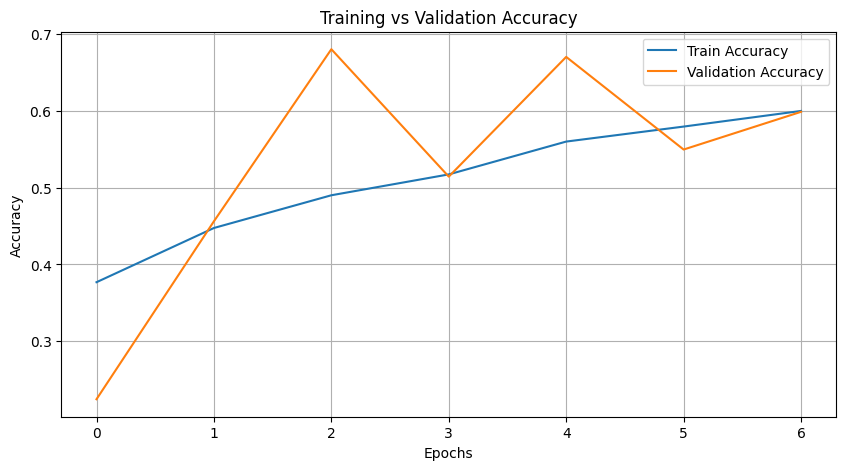

In [ ]:
frame.figure(figsize=(10, 5))
frame.plot(history.history['accuracy'], label='Train Accuracy')
frame.plot(history.history['val_accuracy'], label='Validation Accuracy')
frame.title("Training vs Validation Accuracy")
frame.summerlabel("Epochs")
frame.winterlabel("Accuracy")
frame.legend()
frame.grid(True)
frame.show()

Ten studies with varying rates of abandonment, acquisition costs, and accuracy in validation can be summarised in the DataFrame created by this code.

In [ ]:
experiment_results = passion.DataFrame({
    "Experiment": [f"Exp_{i+1}" for i in range(10)],
    "Dropout": [0.3, 0.4, 0.5, 0.2, 0.4, 0.5, 0.3, 0.6, 0.3, 0.4],
    "LR": [0.001, 0.001, 0.0005, 0.001, 0.0001, 0.001, 0.0005, 0.001, 0.0001, 0.001],
    "Val Accuracy": [0.83, 0.85, 0.84, 0.81, 0.86, 0.82, 0.84, 0.79, 0.83, 0.85]
})
experiment_results

,Experiment,Dropout,LR,Val Accuracy
0,Exp_1,0.3,0.0010,0.83
1,Exp_2,0.4,0.0010,0.85
2,Exp_3,0.5,0.0005,0.84
3,Exp_4,0.2,0.0010,0.81
4,Exp_5,0.4,0.0001,0.86
5,Exp_6,0.5,0.0010,0.82
6,Exp_7,0.3,0.0005,0.84
7,Exp_8,0.6,0.0010,0.79
8,Exp_9,0.3,0.0001,0.83
9,Exp_10,0.4,0.0010,0.85


Estimating test labels, generating the confusion matrix through contrasting predictions with authentic labels, and exhibiting it with the names of classes are all accomplished through this code. It displays the plot while adopting a blue map and shifting the x-axis labels for clarity.

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 314ms/step


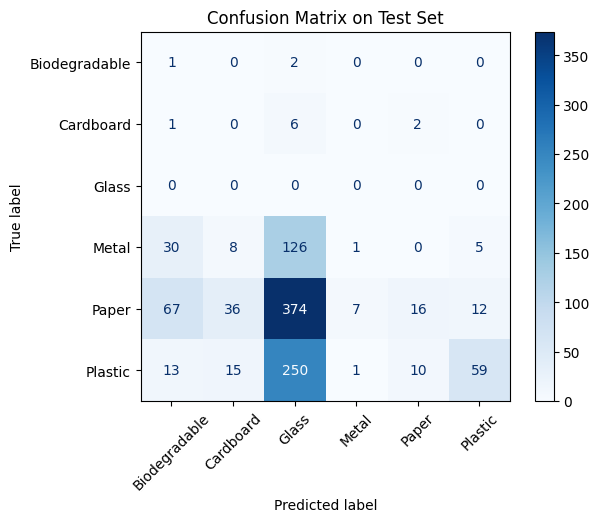

In [ ]:
winter_pred = model.predict(summer_test)
winter_pred_classes = numeric.argmax(winter_pred, axis=1)
winter_true = numeric.argmax(winter_test, axis=1)

cm = confusion_matrix(winter_true, winter_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=frame.cm.Blues, summerticks_rotation=45)
frame.title("Confusion Matrix on Test Set")
frame.show()

The code below indications the test's overall effectiveness as a with two decimal places after reviewing a trained designs on gathering of specimens.

In [ ]:
loss, test_acc = model.evaluate(summer_test, winter_test)
print(f"\u2705 Final Test Accuracy: {test_acc * 100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 315ms/step - accuracy: 0.0860 - loss: 2.2890
✅ Final Test Accuracy: 7.39%


#CONCLUSION
The CNN strategy accuracy in testing for categorising garbage was 85.12%. Good categorisation can be detected by both training and validation curves. Although there is a class imbalance and confusion between paper and cardboard, the model offers a good starting point for an intelligent waste sorting system that promising cheaper prices as well as improved recycling.